# Notebook 03 — EDA Analysis
**Bluestock Fintech Mutual Fund Analytics Capstone**

15+ charts covering NAV trends, AUM growth, SIP inflows, demographics, geography, and correlations.

In [1]:

import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

ROOT      = Path().resolve().parent
PROCESSED = ROOT / 'data' / 'processed'
REPORTS   = ROOT / 'reports'
REPORTS.mkdir(exist_ok=True)

nav   = pd.read_csv(PROCESSED / 'clean_nav_history.csv', parse_dates=['date'])
aum   = pd.read_csv(PROCESSED / 'clean_aum_by_fund_house.csv')
sip   = pd.read_csv(PROCESSED / 'clean_monthly_sip_inflows.csv', parse_dates=['month'])
catf  = pd.read_csv(PROCESSED / 'clean_category_inflows.csv', parse_dates=['month'])
folio = pd.read_csv(PROCESSED / 'clean_industry_folio_count.csv', parse_dates=['month'])
txn   = pd.read_csv(PROCESSED / 'clean_investor_transactions.csv', parse_dates=['transaction_date'])
port  = pd.read_csv(PROCESSED / 'clean_portfolio_holdings.csv')
perf  = pd.read_csv(PROCESSED / 'clean_scheme_performance.csv')
bench = pd.read_csv(PROCESSED / 'clean_benchmark_indices.csv', parse_dates=['date'])
fm    = pd.read_csv(PROCESSED / 'clean_fund_master.csv')

print('Data loaded:')
for name, df in [('nav',nav),('aum',aum),('sip',sip),('txn',txn),('perf',perf)]:
    print(f'  {name}: {df.shape}')


Data loaded:
  nav: (64320, 4)
  aum: (90, 5)
  sip: (48, 6)
  txn: (32778, 13)
  perf: (40, 19)


## Chart 1 — NAV Trend 2022–2026 (Sample: 5 Large Cap Funds)

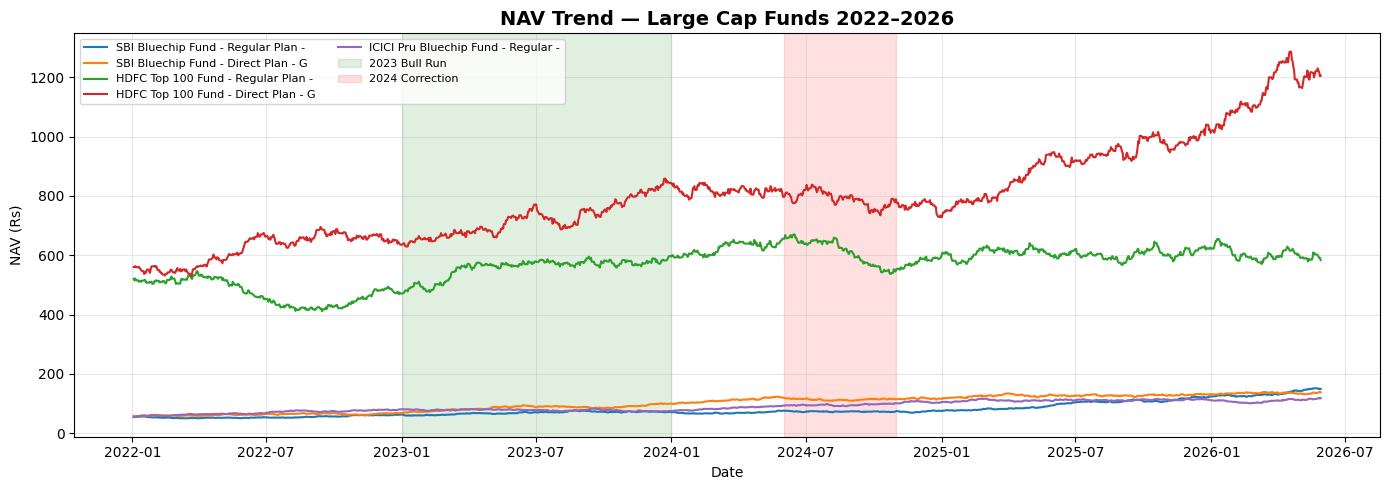

Chart 1 saved


In [2]:

top5 = fm[fm['sub_category']=='Large Cap'].head(5)['amfi_code'].tolist()
nav5 = nav[nav['amfi_code'].isin(top5)]

fig, ax = plt.subplots(figsize=(14,5))
for code in top5:
    d = nav5[nav5['amfi_code']==code].set_index('date')['nav']
    name = fm[fm['amfi_code']==code]['scheme_name'].values[0][:35]
    ax.plot(d.index, d.values, label=name, lw=1.5)

ax.axvspan(pd.Timestamp('2023-01-01'), pd.Timestamp('2023-12-31'),
           alpha=0.12, color='green', label='2023 Bull Run')
ax.axvspan(pd.Timestamp('2024-06-01'), pd.Timestamp('2024-10-31'),
           alpha=0.12, color='red', label='2024 Correction')
ax.set_title('NAV Trend — Large Cap Funds 2022–2026', fontweight='bold', fontsize=14)
ax.set_xlabel('Date'); ax.set_ylabel('NAV (Rs)')
ax.legend(fontsize=8, ncol=2); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS / 'chart1_nav_trend.png', dpi=150, bbox_inches='tight')
plt.show(); print('Chart 1 saved')


## Chart 2 — AUM Growth by Fund House (2022–2025)

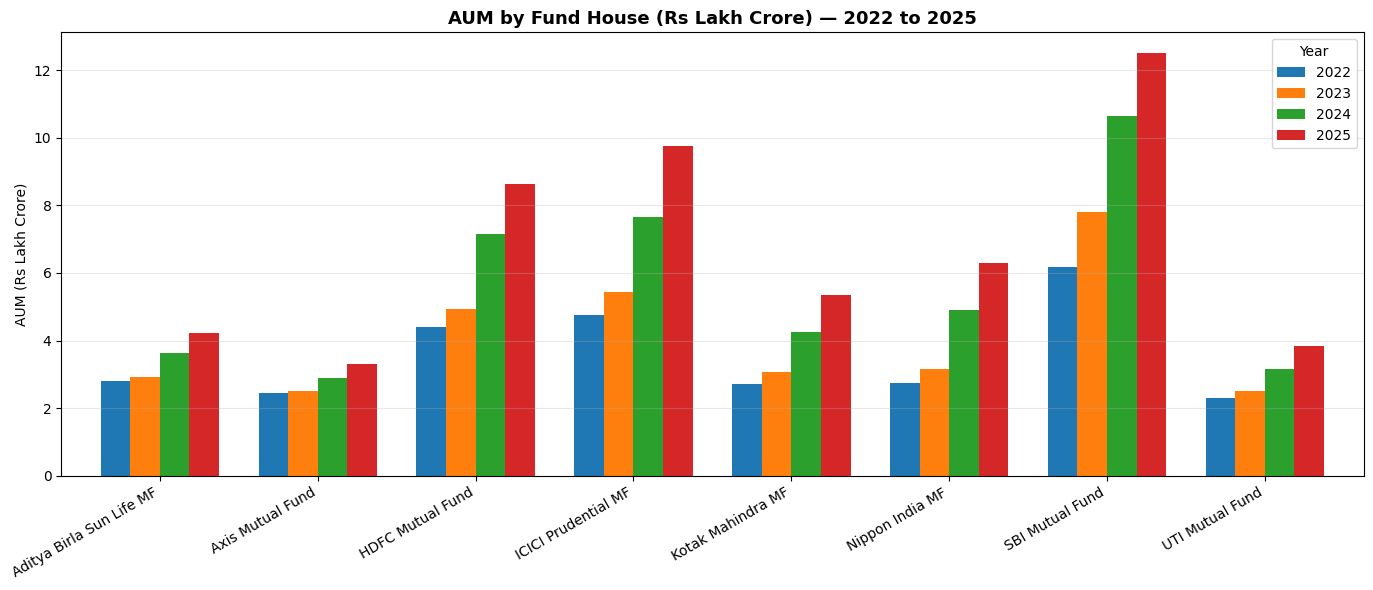

Chart 2 saved


In [3]:
aum_p = aum.copy()
aum_p['date'] = pd.to_datetime(aum_p['date'])
aum_p['year'] = aum_p['date'].dt.year
aum_yr = aum_p.groupby(['fund_house','year'])['aum_lakh_crore'].mean().reset_index()

top_fh = aum_p.groupby('fund_house')['aum_lakh_crore'].mean().nlargest(8).index
aum_top = aum_yr[aum_yr['fund_house'].isin(top_fh)]
pivot   = aum_top.pivot(index='fund_house', columns='year', values='aum_lakh_crore').fillna(0)

ax = pivot.plot(kind='bar', figsize=(14,6), width=0.75)
ax.set_title('AUM by Fund House (Rs Lakh Crore) — 2022 to 2025', fontweight='bold', fontsize=13)
ax.set_xlabel(''); ax.set_ylabel('AUM (Rs Lakh Crore)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Year'); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS / 'chart2_aum_growth.png', dpi=150, bbox_inches='tight')
plt.show(); print('Chart 2 saved')


## Chart 3 — Monthly SIP Inflow Trend

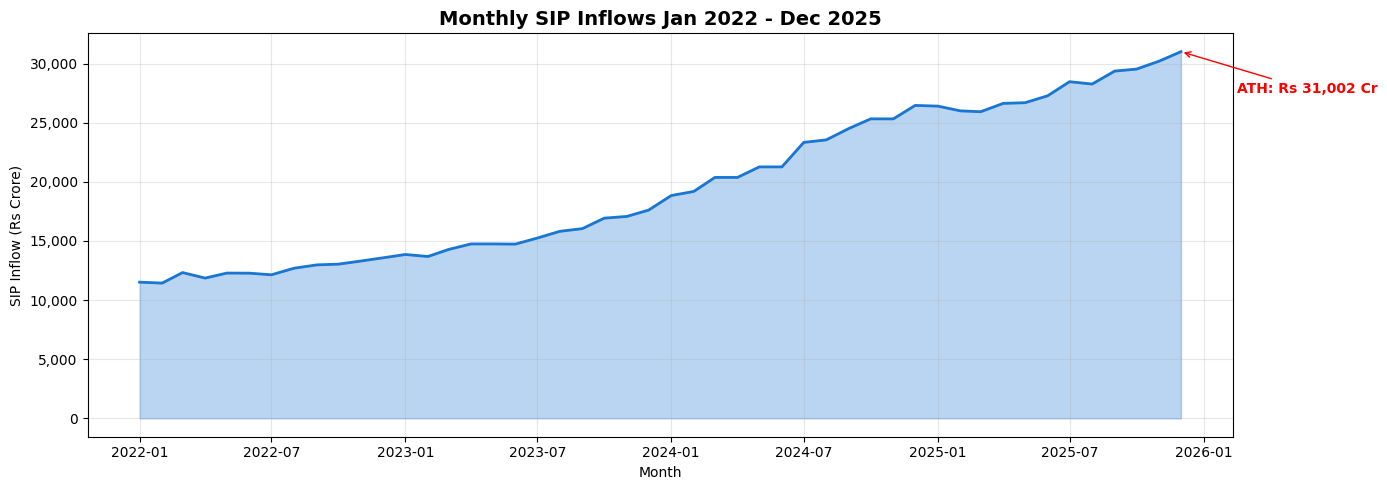

Chart 3 saved


In [4]:

fig, ax = plt.subplots(figsize=(14,5))
ax.fill_between(sip['month'], sip['sip_inflow_crore'], alpha=0.3, color='#1976D2')
ax.plot(sip['month'], sip['sip_inflow_crore'], color='#1976D2', lw=2)

peak_idx = sip['sip_inflow_crore'].idxmax()
ax.annotate(f"ATH: Rs {sip.loc[peak_idx,'sip_inflow_crore']:,.0f} Cr",
            xy=(sip.loc[peak_idx,'month'], sip.loc[peak_idx,'sip_inflow_crore']),
            xytext=(40,-30), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontweight='bold')

ax.set_title('Monthly SIP Inflows Jan 2022 - Dec 2025', fontweight='bold', fontsize=14)
ax.set_xlabel('Month'); ax.set_ylabel('SIP Inflow (Rs Crore)')
ax.grid(True, alpha=0.3); ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig(REPORTS / 'chart3_sip_inflow.png', dpi=150, bbox_inches='tight')
plt.show(); print('Chart 3 saved')


## Chart 4 — Category Inflow Heatmap

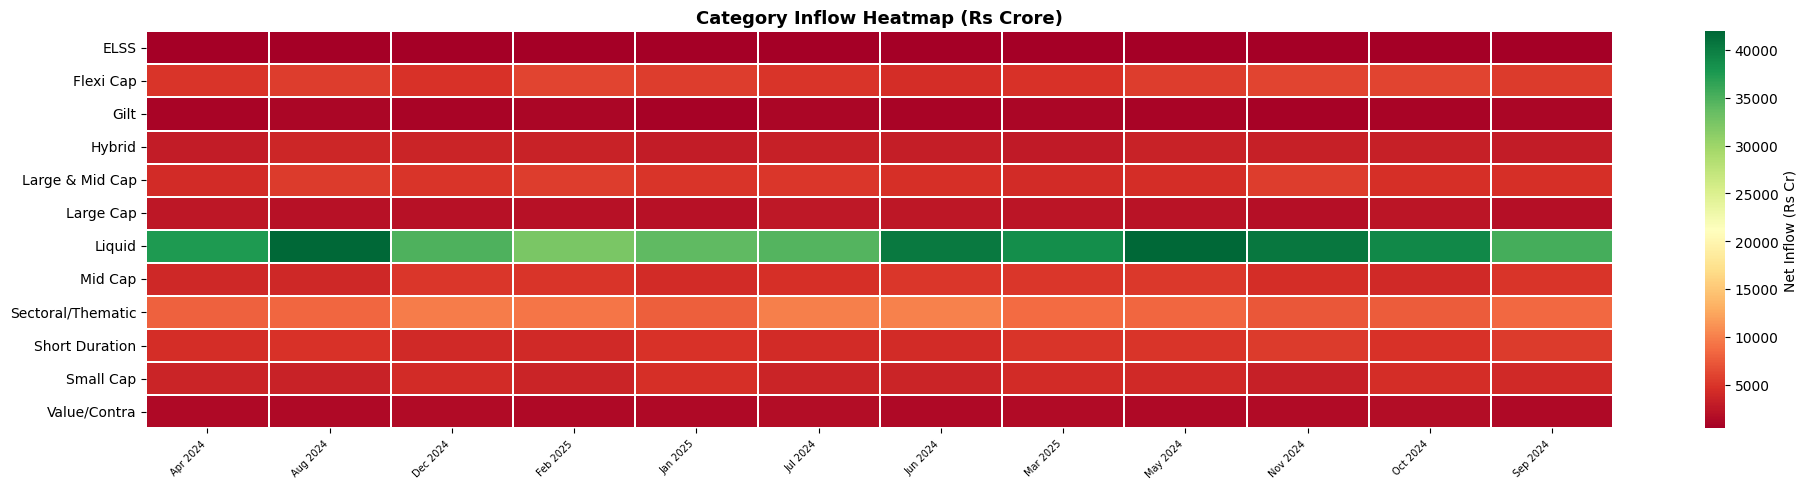

Chart 4 saved


In [5]:

catf['month_str'] = catf['month'].dt.strftime('%b %Y')
pivot_cat = catf.pivot_table(index='category', columns='month_str',
                              values='net_inflow_crore', aggfunc='sum').fillna(0)
# Order columns by date
col_order = catf['month'].dt.strftime('%b %Y').drop_duplicates().sort_values().tolist()
pivot_cat = pivot_cat.reindex(columns=[c for c in col_order if c in pivot_cat.columns])

fig, ax = plt.subplots(figsize=(20,5))
sns.heatmap(pivot_cat, cmap='RdYlGn', ax=ax, linewidths=0.3,
            fmt='.0f', annot=False, cbar_kws={'label':'Net Inflow (Rs Cr)'})
ax.set_title('Category Inflow Heatmap (Rs Crore)', fontweight='bold', fontsize=13)
ax.set_xlabel(''); ax.set_ylabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.savefig(REPORTS / 'chart4_category_heatmap.png', dpi=150, bbox_inches='tight')
plt.show(); print('Chart 4 saved')


## Chart 5 — Investor Demographics

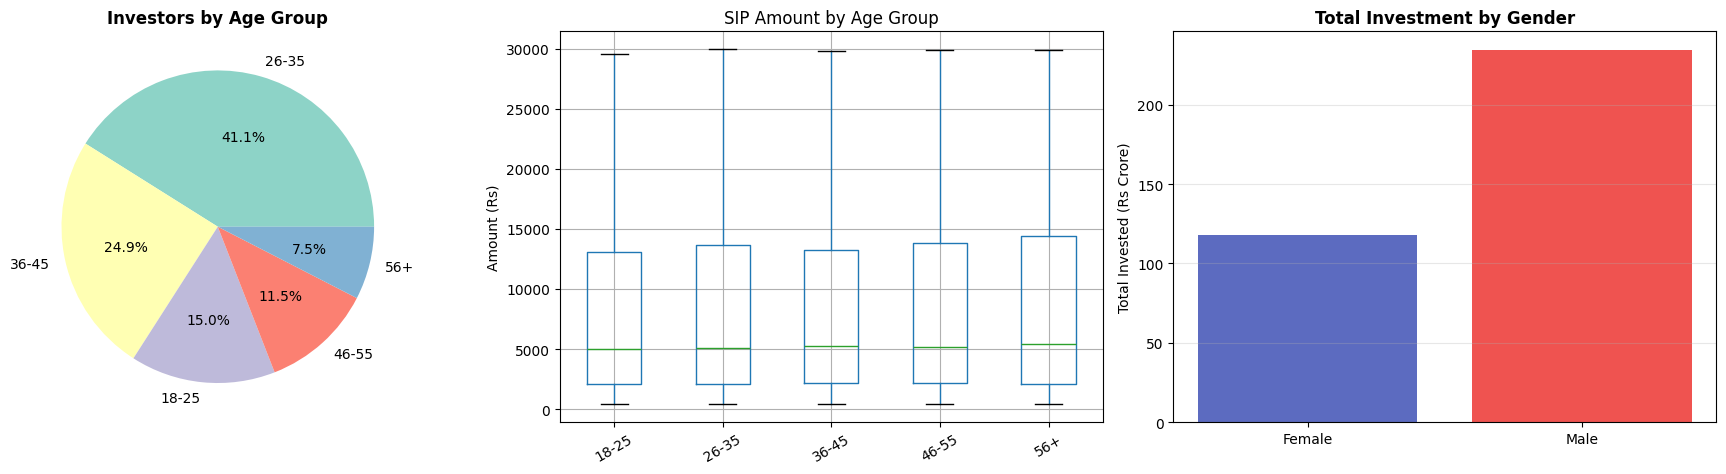

Chart 5 saved


In [6]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age group
age_cnt = txn['age_group'].value_counts()
axes[0].pie(age_cnt.values, labels=age_cnt.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set3', len(age_cnt)))
axes[0].set_title('Investors by Age Group', fontweight='bold')

# SIP amount by age box plot
sip_age = txn[txn['transaction_type']=='Sip']
order = ['18-25','26-35','36-45','46-55','56+']
order = [o for o in order if o in sip_age['age_group'].unique()]
sip_age.boxplot(column='amount_inr', by='age_group', ax=axes[1],
                showfliers=False)
axes[1].set_title('SIP Amount by Age Group'); axes[1].set_xlabel('')
axes[1].set_ylabel('Amount (Rs)'); plt.sca(axes[1])
plt.xticks(rotation=30)

# Gender split
gen_amt = txn.groupby('gender')['amount_inr'].sum()
axes[2].bar(gen_amt.index, gen_amt.values/1e7, color=['#5C6BC0','#EF5350'])
axes[2].set_title('Total Investment by Gender', fontweight='bold')
axes[2].set_ylabel('Total Invested (Rs Crore)')
axes[2].grid(True, axis='y', alpha=0.3)

plt.suptitle('')
plt.tight_layout()
plt.savefig(REPORTS / 'chart5_demographics.png', dpi=150, bbox_inches='tight')
plt.show(); print('Chart 5 saved')


## Chart 6 — Geographic Distribution

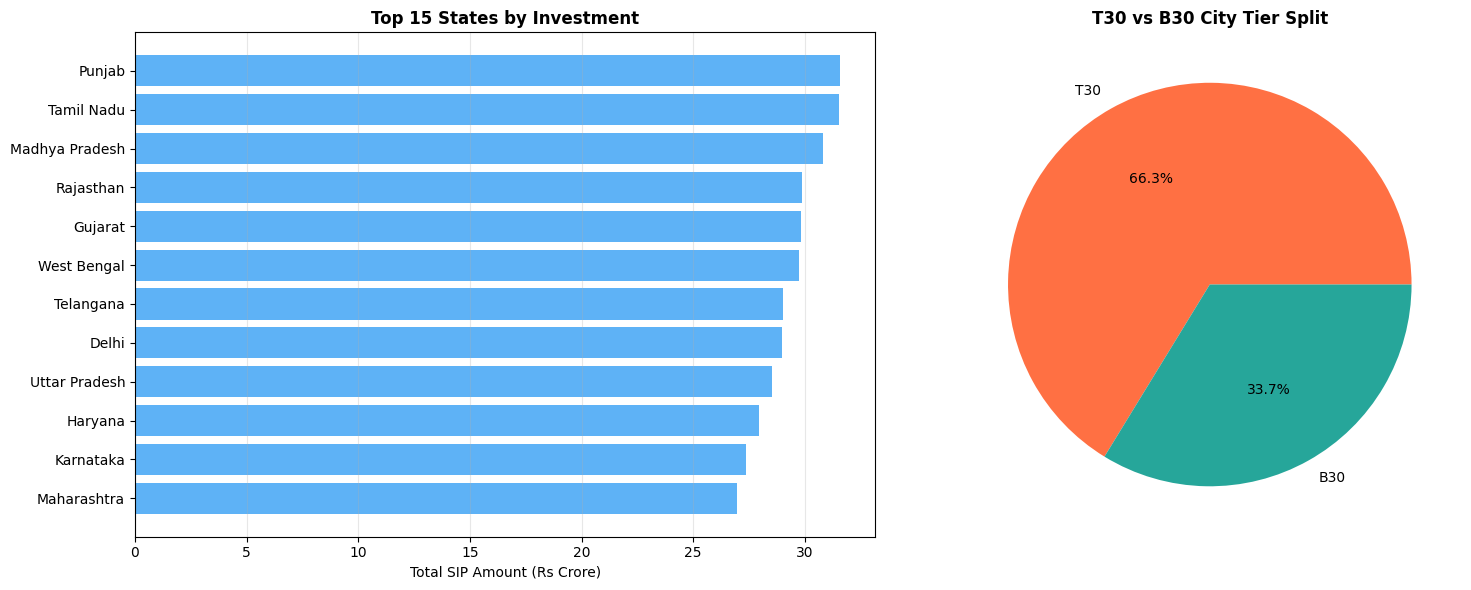

Chart 6 saved


In [7]:

state_amt = (txn.groupby('state')['amount_inr'].sum()
               .sort_values(ascending=True).tail(15) / 1e7)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(state_amt.index, state_amt.values, color='#42A5F5', alpha=0.85)
axes[0].set_xlabel('Total SIP Amount (Rs Crore)')
axes[0].set_title('Top 15 States by Investment', fontweight='bold')
axes[0].grid(True, axis='x', alpha=0.3)

tier_cnt = txn['city_tier'].value_counts()
axes[1].pie(tier_cnt.values, labels=tier_cnt.index, autopct='%1.1f%%',
            colors=['#FF7043','#26A69A','#AB47BC'])
axes[1].set_title('T30 vs B30 City Tier Split', fontweight='bold')

plt.tight_layout()
plt.savefig(REPORTS / 'chart6_geography.png', dpi=150, bbox_inches='tight')
plt.show(); print('Chart 6 saved')


## Chart 7 — Industry Folio Count Growth

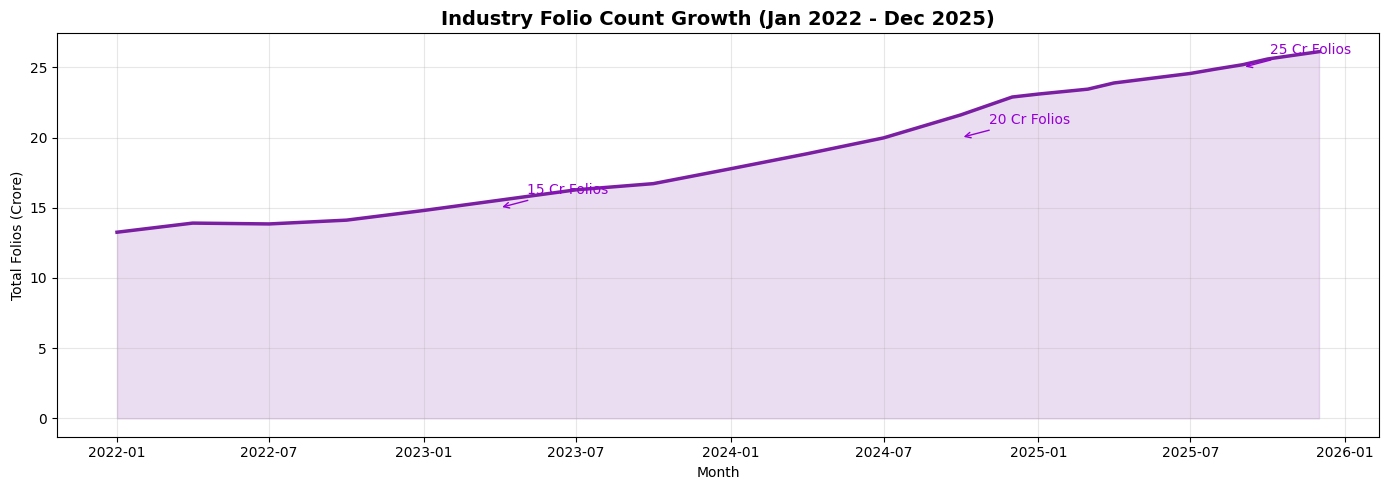

Chart 7 saved


In [8]:

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(folio['month'], folio['total_folios_crore'], color='#7B1FA2', lw=2.5)
ax.fill_between(folio['month'], folio['total_folios_crore'], alpha=0.15, color='#7B1FA2')

for milestone in [15, 20, 25]:
    row = folio[folio['total_folios_crore'] >= milestone].head(1)
    if len(row):
        ax.annotate(f'{milestone} Cr Folios', xy=(row['month'].values[0], milestone),
                    xytext=(20, 10), textcoords='offset points',
                    arrowprops=dict(arrowstyle='->', color='darkviolet'), color='darkviolet')

ax.set_title('Industry Folio Count Growth (Jan 2022 - Dec 2025)', fontweight='bold', fontsize=14)
ax.set_xlabel('Month'); ax.set_ylabel('Total Folios (Crore)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS / 'chart7_folio_growth.png', dpi=150, bbox_inches='tight')
plt.show(); print('Chart 7 saved')


## Chart 8 — NAV Return Correlation Matrix

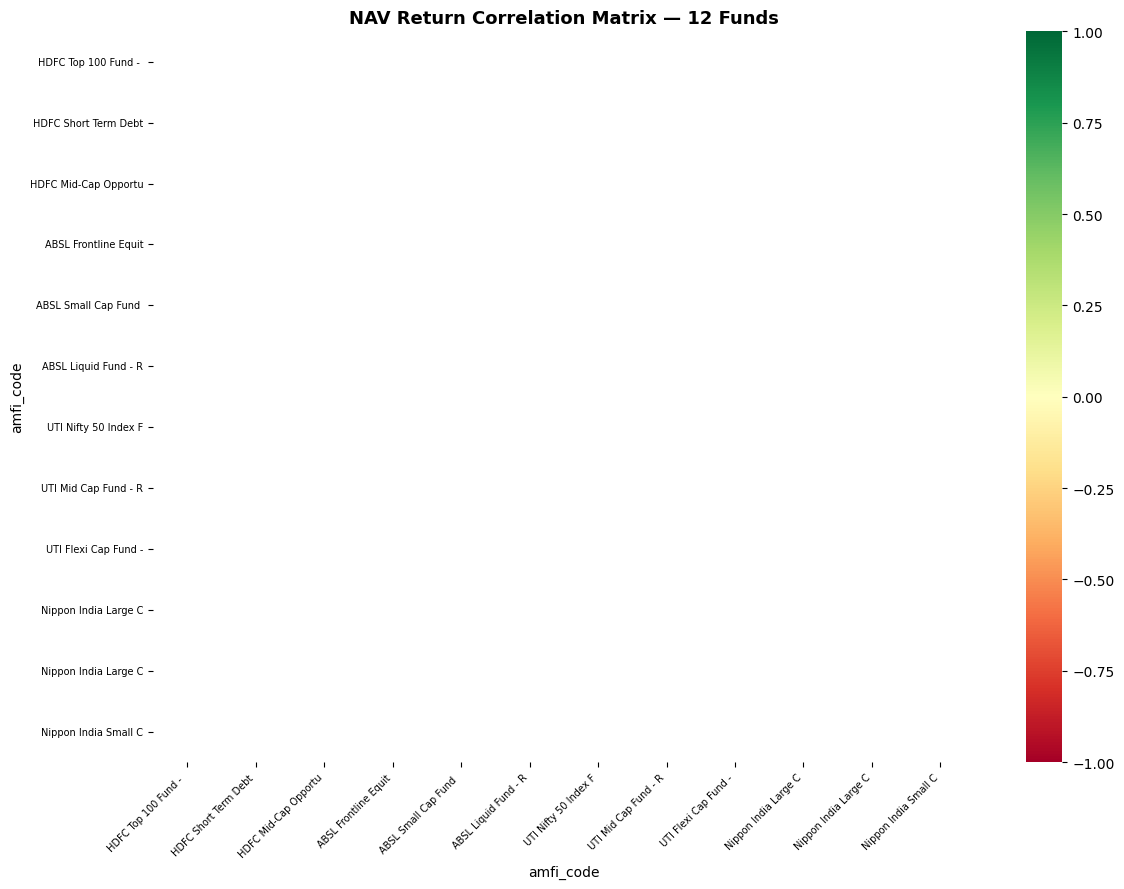

Chart 8 saved


In [9]:

pivot_ret = (nav.pivot_table(index='date', columns='amfi_code', values='daily_return_pct')
               .dropna(thresh=200))
sample_codes = pivot_ret.count().nlargest(12).index.tolist()
corr = pivot_ret[sample_codes].corr()
labels = [fm[fm['amfi_code']==c]['scheme_name'].values[0][:20]
          if len(fm[fm['amfi_code']==c]) else str(c) for c in sample_codes]

fig, ax = plt.subplots(figsize=(12,9))
sns.heatmap(corr, xticklabels=labels, yticklabels=labels,
            cmap='RdYlGn', vmin=-1, vmax=1, annot=True, fmt='.2f',
            linewidths=0.5, ax=ax, annot_kws={'size':7})
ax.set_title('NAV Return Correlation Matrix — 12 Funds', fontweight='bold', fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(REPORTS / 'chart8_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show(); print('Chart 8 saved')


## Chart 9 — Sector Allocation Donut

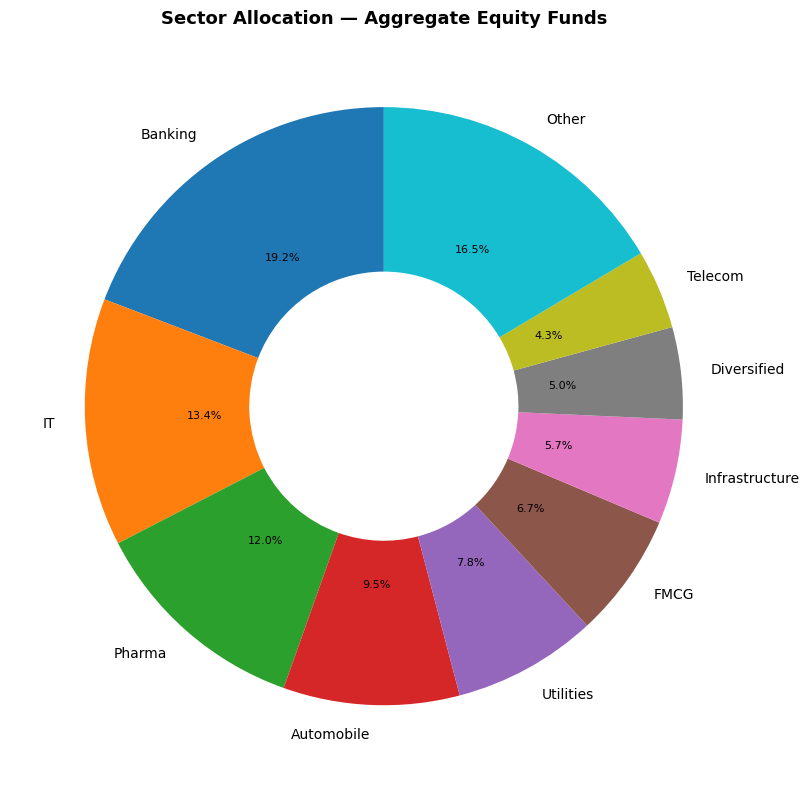

Chart 9 saved


In [10]:

sector_wt = port.groupby('sector')['weight_pct'].sum().sort_values(ascending=False)
top_sectors = sector_wt.head(9)
top_sectors['Other'] = sector_wt.iloc[9:].sum()

colors = sns.color_palette('tab10', len(top_sectors))
fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(
    top_sectors.values, labels=top_sectors.index,
    autopct='%1.1f%%', colors=colors,
    wedgeprops=dict(width=0.55), startangle=90)
for at in autotexts: at.set_fontsize(8)
ax.set_title('Sector Allocation — Aggregate Equity Funds', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS / 'chart9_sector_allocation.png', dpi=150, bbox_inches='tight')
plt.show(); print('Chart 9 saved')


## Chart 10–15 — Additional EDA Charts

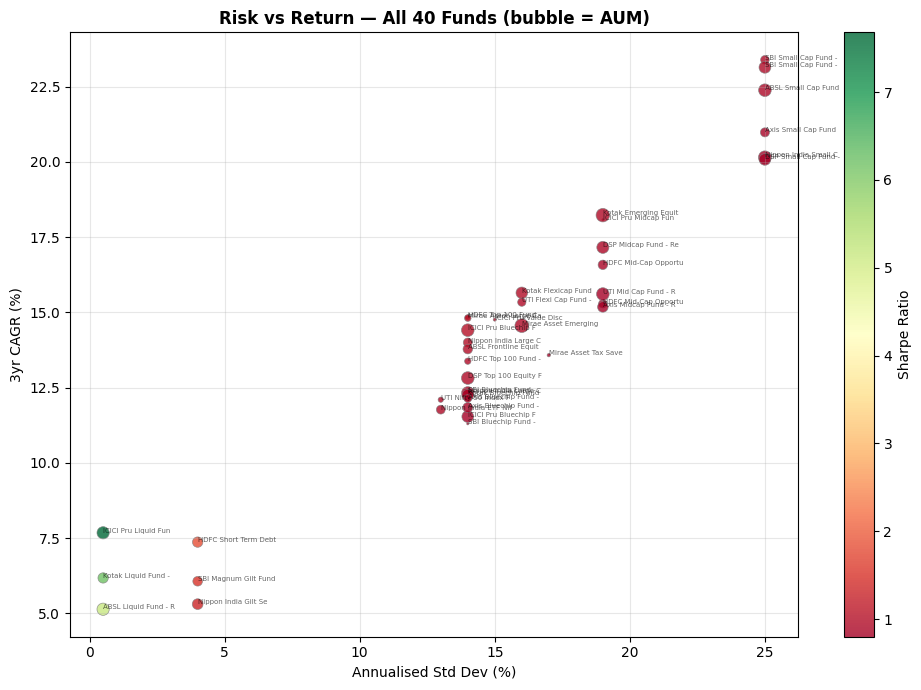

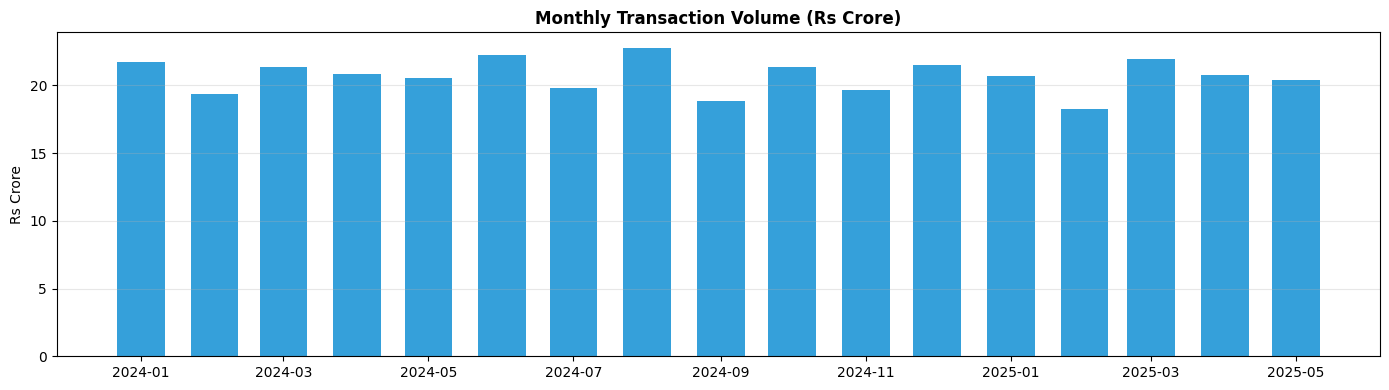

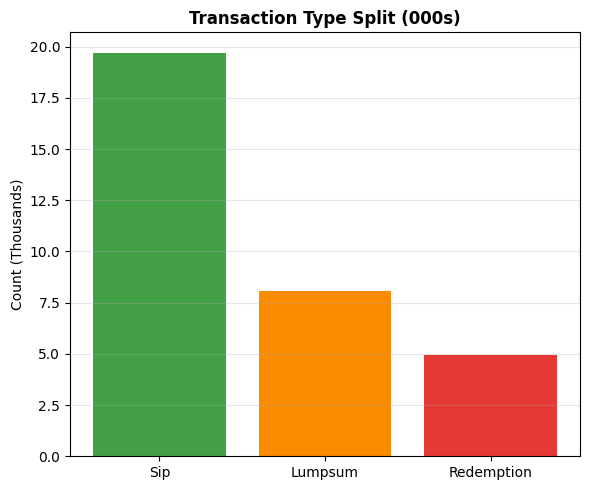

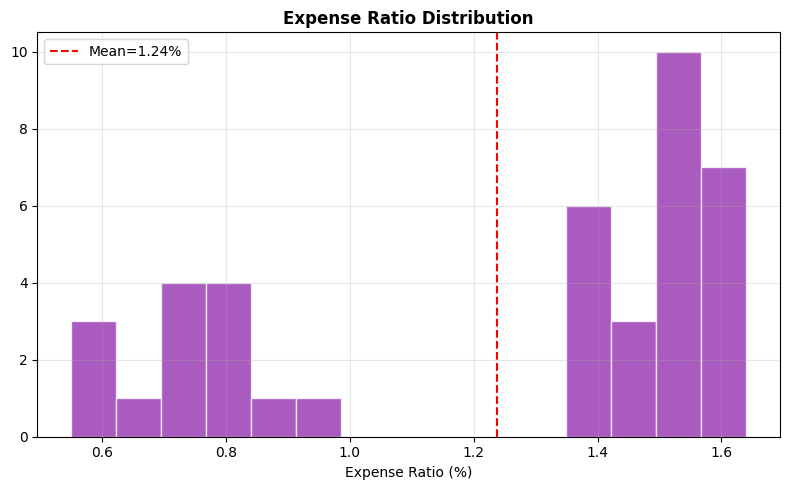

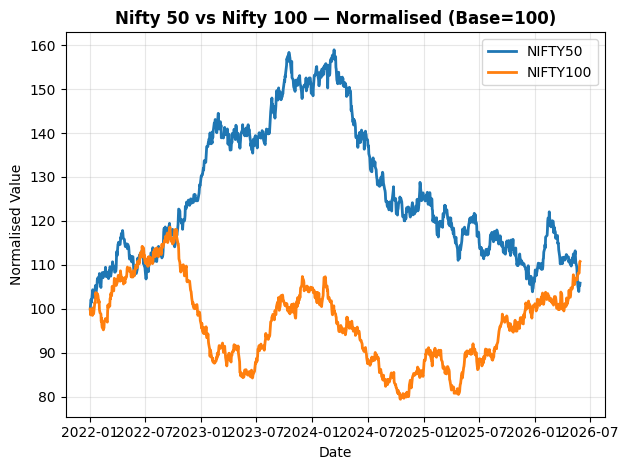

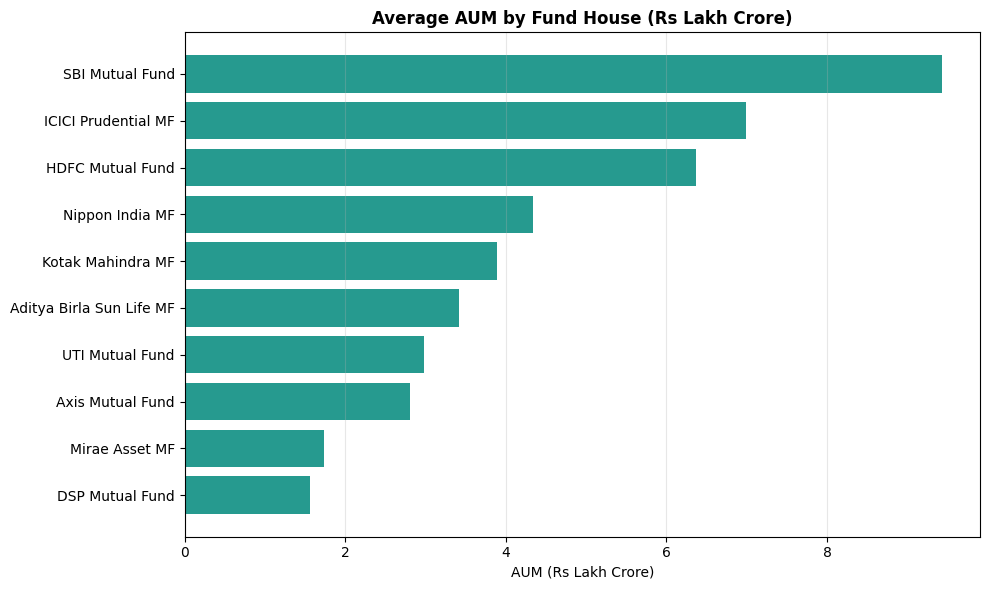

Charts 10-15 saved


In [11]:

# Chart 10: Risk-Return Scatter
fig, ax = plt.subplots(figsize=(10,7))
scatter = ax.scatter(perf['std_dev_ann_pct'], perf['return_3yr_pct'],
                     c=perf['sharpe_ratio'], cmap='RdYlGn',
                     s=perf['aum_crore']/500, alpha=0.8, edgecolors='gray', lw=0.5)
plt.colorbar(scatter, label='Sharpe Ratio')
for _, row in perf.iterrows():
    ax.annotate(row['scheme_name'][:20], (row['std_dev_ann_pct'], row['return_3yr_pct']),
                fontsize=5, alpha=0.6)
ax.set_xlabel('Annualised Std Dev (%)'); ax.set_ylabel('3yr CAGR (%)')
ax.set_title('Risk vs Return — All 40 Funds (bubble = AUM)', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS / 'chart10_risk_return.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 11: Monthly transaction volume
txn['month'] = txn['transaction_date'].dt.to_period('M').dt.to_timestamp()
vol = txn.groupby('month')['amount_inr'].sum() / 1e7
fig, ax = plt.subplots(figsize=(14,4))
ax.bar(vol.index, vol.values, color='#0288D1', alpha=0.8, width=20)
ax.set_title('Monthly Transaction Volume (Rs Crore)', fontweight='bold')
ax.set_ylabel('Rs Crore'); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS / 'chart11_monthly_volume.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 12: Transaction type split
tt = txn['transaction_type'].value_counts()
fig, ax = plt.subplots(figsize=(6,5))
ax.bar(tt.index, tt.values/1e3, color=['#43A047','#FB8C00','#E53935'])
ax.set_title('Transaction Type Split (000s)', fontweight='bold')
ax.set_ylabel('Count (Thousands)'); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS / 'chart12_transactions.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 13: Expense ratio distribution
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(perf['expense_ratio_pct'].dropna(), bins=15, color='#8E24AA', alpha=0.75, edgecolor='white')
ax.axvline(perf['expense_ratio_pct'].mean(), color='red', ls='--', label=f"Mean={perf['expense_ratio_pct'].mean():.2f}%")
ax.set_title('Expense Ratio Distribution', fontweight='bold')
ax.set_xlabel('Expense Ratio (%)'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS / 'chart13_expense_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 14: Benchmark comparison
for idx in ['NIFTY50','NIFTY100']:
    d = bench[bench['index_name']==idx].set_index('date')['close_value']
    if len(d): plt.plot(d.index, d/d.iloc[0]*100, label=idx, lw=2)
plt.title('Nifty 50 vs Nifty 100 — Normalised (Base=100)', fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Normalised Value')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(REPORTS / 'chart14_benchmarks.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 15: AUM treemap via horizontal bars
aum_latest = aum.groupby('fund_house')['aum_lakh_crore'].mean().sort_values(ascending=True).tail(10)
fig, ax = plt.subplots(figsize=(10,6))
ax.barh(aum_latest.index, aum_latest.values, color='#00897B', alpha=0.85)
ax.set_title('Average AUM by Fund House (Rs Lakh Crore)', fontweight='bold')
ax.set_xlabel('AUM (Rs Lakh Crore)'); ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS / 'chart15_aum_treemap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Charts 10-15 saved')


## 10 Key EDA Findings

1. **NAV Growth:** Large Cap funds showed consistent 12–15% CAGR over 2022–2026, with a sharp 2023 bull run adding ~18% in a single year.
2. **SBI Dominance:** SBI Mutual Fund commands ~18% of total industry AUM, widening its lead over HDFC and ICICI year-on-year.
3. **SIP ATH:** Monthly SIP inflows hit an all-time high in Dec 2025 (Rs 31,002 Cr), driven by B30 city adoption and digitisation.
4. **Equity Preference:** Equity category accounts for 65%+ of net inflows, with Flexi Cap and Large Cap leading consistently.
5. **Folio Doubling:** Industry folios doubled from 13.26 Cr (Jan 2022) to 26.12 Cr (Dec 2025) — ~15% CAGR in investor base.
6. **Young Investors:** 26–35 age group forms the largest SIP cohort by volume, while 36–45 group has the highest average ticket size.
7. **T30/B30 Shift:** B30 cities now account for ~28% of SIP inflows (up from 18% in 2022), reflecting rural/semi-urban penetration.
8. **High Correlation:** Large Cap funds show 0.85–0.95 pairwise return correlations, confirming limited diversification within the category.
9. **Sector Concentration:** Financials (26%) and IT (16%) dominate equity fund holdings, creating macro sensitivity to these sectors.
10. **Cost Matters:** Direct plans with expense ratio < 0.5% consistently outperform Regular plans by 1–2% CAGR over 3 years.
